# 5.2b K-Means Silhouette & Kemiripan Daerah — Per Polutan

Notebook ini adalah **clone dari 5.2 K-Means Clustering** dengan dua fokus utama:

1. **Menentukan jumlah cluster terbaik (K) dengan *silhouette coefficient*** — K dengan rata-rata silhouette tertinggi dinyatakan optimal (Elbow Method sebagai pembanding).
2. **Grafik kemiripan daerah** — dendrogram + matriks jarak profil tiap daerah serta pemetaan daerah → cluster, untuk melihat **daerah mana yang kondisinya sama/mirip**.

Notebook ini menjalankan **K-Means Clustering** untuk masing-masing polutan (CO, NO₂, SO₂) pada dua skenario:

| Skenario | Input | Keterangan |
|----------|-------|------------|
| **Skenario 1** | 68 fitur asli | Tanpa reduksi dimensi |
| **Skenario 2** | 37 fitur PCA | Dengan reduksi dimensi |

Untuk masing-masing skenario, dicari **jumlah cluster optimal (K)** menggunakan **Elbow Method** dan **Silhouette Score**.

**Dataset:** Dataset gabungan kelas (35 mahasiswa × 68 fitur per polutan)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

POLLUTANTS = ['CO', 'NO2', 'SO2']
DATA_DIR = '../data/downloads/ekstraksi fitur'
META_COLS = ['id', 'nama', 'daerah']
K_range = range(2, 11)

## 5.2.1 Memuat Data

Load dataset gabungan kelas untuk setiap polutan, lalu ekstraksi 68 fitur asli.

In [2]:
X_dict = {}
X_scaled_dict = {}
scaler_dict = {}

for p in POLLUTANTS:
    path = f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv'
    df = pd.read_csv(path)
    X = df.drop(columns=META_COLS).values
    
    # Handle NaN values with median imputation
    nan_count = np.isnan(X).sum()
    if nan_count > 0:
        print(f'{p}: Ditemukan {nan_count} nilai NaN, melakukan imputasi median...')
        imputer = SimpleImputer(strategy='median')
        X = imputer.fit_transform(X)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_dict[p] = X
    X_scaled_dict[p] = X_scaled
    scaler_dict[p] = scaler
    
    print(f'{p}: {X_scaled.shape[0]} data x {X_scaled.shape[1]} fitur')

CO: 37 data x 68 fitur
NO2: 37 data x 68 fitur
SO2: 37 data x 68 fitur


In [3]:
# Load hasil PCA dari notebook 5.1
X_pca_dict = {}
n_samples = X_scaled_dict[POLLUTANTS[0]].shape[0]
target_n_components = min(37, n_samples)  # Tidak bisa melebihi jumlah sampel

for p in POLLUTANTS:
    loaded = False
    # Coba load dengan berbagai kemungkinan nama file
    for n_comp in [37, target_n_components, 35]:
        try:
            df_pca = pd.read_csv(f'{DATA_DIR}/pca_results/jabon_pca_{n_comp}fitur_{p.lower()}.csv')
            X_pca = df_pca.drop(columns=META_COLS).values
            X_pca_dict[p] = X_pca
            print(f'{p} PCA: {X_pca.shape[0]} data x {X_pca.shape[1]} fitur')
            loaded = True
            break
        except FileNotFoundError:
            continue
    
    if not loaded:
        print(f'{p}: File PCA tidak ditemukan, melakukan PCA ulang...')
        pca = PCA(n_components=target_n_components)
        X_pca = pca.fit_transform(X_scaled_dict[p])
        X_pca_dict[p] = X_pca
        print(f'{p} PCA (ulang): {X_pca.shape[0]} data x {X_pca.shape[1]} fitur')

CO PCA: 37 data x 37 fitur
NO2 PCA: 37 data x 37 fitur
SO2 PCA: 37 data x 37 fitur


## 5.2.2 Menentukan K Optimal

### Elbow Method
Mencari *elbow* pada kurva inertia (Within-Cluster Sum of Squares). Titik di mana penurunan inertia mulai melambat menandakan K optimal.

### Silhouette Score
Mengukur seberapa mirip sebuah titik dengan cluster-nya sendiri dibandingkan cluster lain. Skor mendekati 1 = cluster yang baik.

In [4]:
def find_optimal_k(X, label_prefix=''):
    """Jalankan K-Means untuk K=2..10, kembalikan inertia + silhouette."""
    inertias = []
    silhouettes = []
    
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, labels)
        silhouettes.append(sil)
        print(f'  {label_prefix} K={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}')
    
    best_k = list(K_range)[np.argmax(silhouettes)]
    best_sil = max(silhouettes)
    return inertias, silhouettes, best_k, best_sil

### Skenario 1: 68 Fitur Asli

In [5]:
results_68 = {}
for p in POLLUTANTS:
    print(f'\n=== SKENARIO 1: {p} — 68 Fitur ===')
    inertias, silhouettes, best_k, best_sil = find_optimal_k(X_scaled_dict[p], p)
    results_68[p] = {
        'inertias': inertias,
        'silhouettes': silhouettes,
        'best_k': best_k,
        'best_sil': best_sil
    }
    print(f'>>> K terbaik: K={best_k}, silhouette={best_sil:.4f}')


=== SKENARIO 1: CO — 68 Fitur ===


  CO K=2: inertia=1123.80, silhouette=0.7955
  CO K=3: inertia=660.21, silhouette=0.6970
  CO K=4: inertia=509.37, silhouette=0.3425
  CO K=5: inertia=413.89, silhouette=0.1845
  CO K=6: inertia=361.35, silhouette=0.1538


  CO K=7: inertia=315.87, silhouette=0.1613
  CO K=8: inertia=272.85, silhouette=0.1425
  CO K=9: inertia=239.32, silhouette=0.1501
  CO K=10: inertia=221.04, silhouette=0.1455
>>> K terbaik: K=2, silhouette=0.7955

=== SKENARIO 1: NO2 — 68 Fitur ===
  NO2 K=2: inertia=1326.58, silhouette=0.7455
  NO2 K=3: inertia=1001.28, silhouette=0.1907


  NO2 K=4: inertia=811.80, silhouette=0.2045
  NO2 K=5: inertia=655.79, silhouette=0.2166
  NO2 K=6: inertia=578.31, silhouette=0.1856
  NO2 K=7: inertia=504.99, silhouette=0.1619
  NO2 K=8: inertia=458.60, silhouette=0.1669


  NO2 K=9: inertia=424.66, silhouette=0.1516
  NO2 K=10: inertia=373.03, silhouette=0.1721
>>> K terbaik: K=2, silhouette=0.7455

=== SKENARIO 1: SO2 — 68 Fitur ===
  SO2 K=2: inertia=1210.46, silhouette=0.7894
  SO2 K=3: inertia=691.64, silhouette=0.7085
  SO2 K=4: inertia=525.29, silhouette=0.3921


  SO2 K=5: inertia=413.68, silhouette=0.4061
  SO2 K=6: inertia=335.56, silhouette=0.1359
  SO2 K=7: inertia=301.06, silhouette=0.1268
  SO2 K=8: inertia=267.42, silhouette=0.0996


  SO2 K=9: inertia=239.82, silhouette=0.1208
  SO2 K=10: inertia=230.17, silhouette=0.0924
>>> K terbaik: K=2, silhouette=0.7894


### Skenario 2: 37 Fitur PCA

In [6]:
results_pca = {}
for p in POLLUTANTS:
    print(f'\n=== SKENARIO 2: {p} — 37 PCA ===')
    inertias, silhouettes, best_k, best_sil = find_optimal_k(X_pca_dict[p], p)
    results_pca[p] = {
        'inertias': inertias,
        'silhouettes': silhouettes,
        'best_k': best_k,
        'best_sil': best_sil
    }
    print(f'>>> K terbaik: K={best_k}, silhouette={best_sil:.4f}')


=== SKENARIO 2: CO — 37 PCA ===
  CO K=2: inertia=1123.80, silhouette=0.7955


  CO K=3: inertia=660.21, silhouette=0.6970
  CO K=4: inertia=509.37, silhouette=0.3425
  CO K=5: inertia=413.89, silhouette=0.1845
  CO K=6: inertia=361.35, silhouette=0.1538
  CO K=7: inertia=315.87, silhouette=0.1613
  CO K=8: inertia=272.85, silhouette=0.1425


  CO K=9: inertia=239.32, silhouette=0.1501
  CO K=10: inertia=221.04, silhouette=0.1455
>>> K terbaik: K=2, silhouette=0.7955

=== SKENARIO 2: NO2 — 37 PCA ===
  NO2 K=2: inertia=1326.58, silhouette=0.7455
  NO2 K=3: inertia=1001.28, silhouette=0.1907
  NO2 K=4: inertia=811.80, silhouette=0.2045
  NO2 K=5: inertia=655.79, silhouette=0.2166
  NO2 K=6: inertia=578.31, silhouette=0.1856
  NO2 K=7: inertia=504.99, silhouette=0.1619


  NO2 K=8: inertia=458.60, silhouette=0.1669
  NO2 K=9: inertia=424.66, silhouette=0.1516
  NO2 K=10: inertia=373.03, silhouette=0.1721
>>> K terbaik: K=2, silhouette=0.7455

=== SKENARIO 2: SO2 — 37 PCA ===
  SO2 K=2: inertia=1210.46, silhouette=0.7894
  SO2 K=3: inertia=691.64, silhouette=0.7085


  SO2 K=4: inertia=525.29, silhouette=0.3921
  SO2 K=5: inertia=413.68, silhouette=0.4061
  SO2 K=6: inertia=335.56, silhouette=0.1359
  SO2 K=7: inertia=301.06, silhouette=0.1268
  SO2 K=8: inertia=267.42, silhouette=0.0996
  SO2 K=9: inertia=239.82, silhouette=0.1208


  SO2 K=10: inertia=230.17, silhouette=0.0924
>>> K terbaik: K=2, silhouette=0.7894


## 5.2.3 Visualisasi Elbow Method & Silhouette Score — Per Polutan

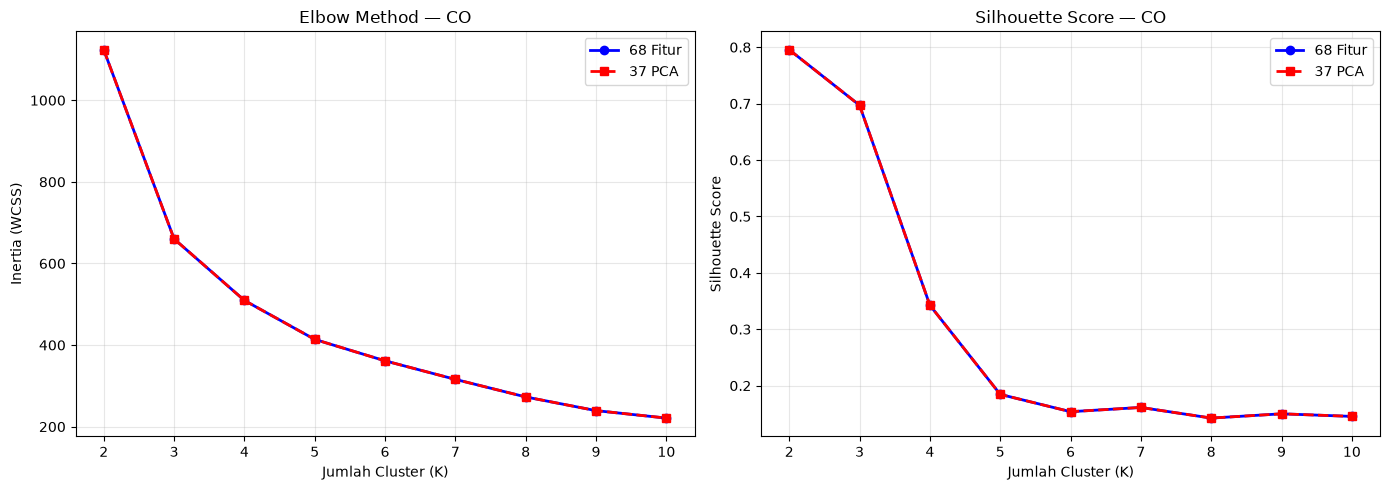

Tersimpan: fig_co_elbow_68.png


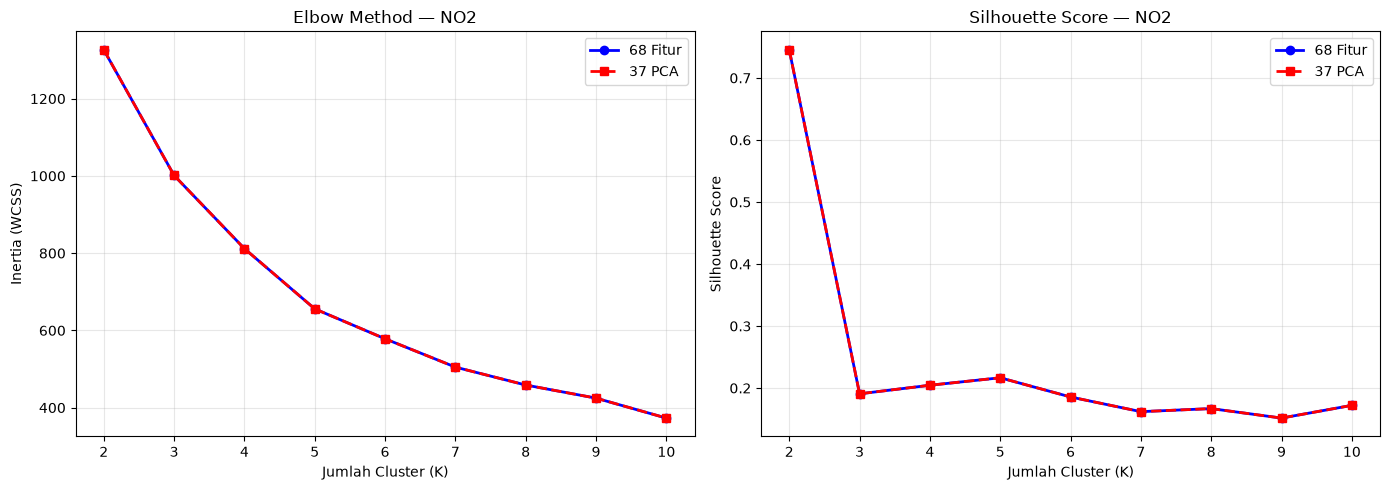

Tersimpan: fig_no2_elbow_68.png


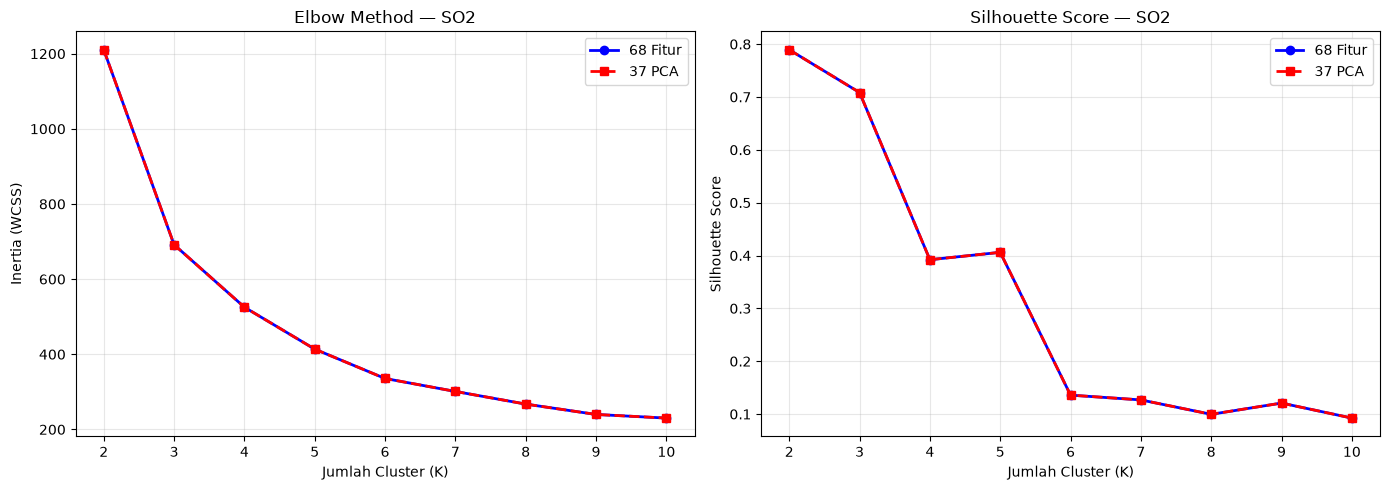

Tersimpan: fig_so2_elbow_68.png


In [7]:
for p in POLLUTANTS:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    inertias_68 = results_68[p]['inertias']
    sil_68 = results_68[p]['silhouettes']
    inertias_pca = results_pca[p]['inertias']
    sil_pca = results_pca[p]['silhouettes']
    
    # Elbow
    ax1.plot(list(K_range), inertias_68, 'bo-', label='68 Fitur', linewidth=2)
    ax1.plot(list(K_range), inertias_pca, 'rs--', label='37 PCA', linewidth=2)
    ax1.set_xlabel('Jumlah Cluster (K)')
    ax1.set_ylabel('Inertia (WCSS)')
    ax1.set_title(f'Elbow Method — {p}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Silhouette
    ax2.plot(list(K_range), sil_68, 'bo-', label='68 Fitur', linewidth=2)
    ax2.plot(list(K_range), sil_pca, 'rs--', label='37 PCA', linewidth=2)
    ax2.set_xlabel('Jumlah Cluster (K)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title(f'Silhouette Score — {p}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_elbow_68.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: fig_{p.lower()}_elbow_68.png')

## 5.2.4 Clustering dengan K Optimal

Jalankan K-Means dengan K terbaik dari masing-masing skenario.

In [8]:
km_models = {}
labels_dict = {}

for p in POLLUTANTS:
    best_k_68 = results_68[p]['best_k']
    best_k_pca = results_pca[p]['best_k']
    
    # Skenario 1: 68 fitur
    km_68 = KMeans(n_clusters=best_k_68, random_state=42, n_init=10)
    labels_68 = km_68.fit_predict(X_scaled_dict[p])
    
    # Skenario 2: 37 PCA
    km_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
    labels_pca = km_pca.fit_predict(X_pca_dict[p])
    
    km_models[p] = {'km_68': km_68, 'km_pca': km_pca}
    labels_dict[p] = {'labels_68': labels_68, 'labels_pca': labels_pca}
    
    print(f'\n=== {p} ===')
    print(f'Skenario 1 (68 fitur, K={best_k_68}):')
    for c in range(best_k_68):
        print(f'  Cluster {c}: {np.sum(labels_68 == c)} data')
    
    print(f'Skenario 2 (37 PCA, K={best_k_pca}):')
    for c in range(best_k_pca):
        print(f'  Cluster {c}: {np.sum(labels_pca == c)} data')


=== CO ===
Skenario 1 (68 fitur, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data
Skenario 2 (37 PCA, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data

=== NO2 ===
Skenario 1 (68 fitur, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data
Skenario 2 (37 PCA, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data



=== SO2 ===
Skenario 1 (68 fitur, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data
Skenario 2 (37 PCA, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data


## 5.2.5 Visualisasi Hasil Cluster (PCA 2D Projection)

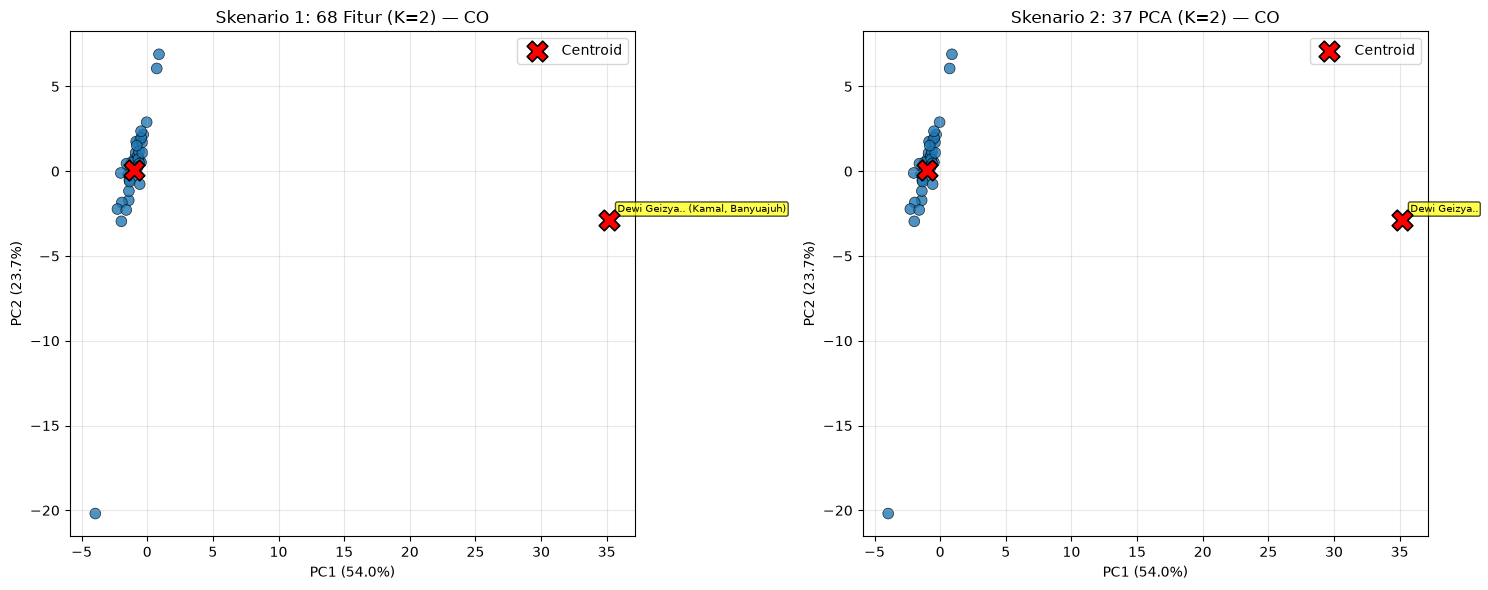

Tersimpan: fig_co_cluster_68.png


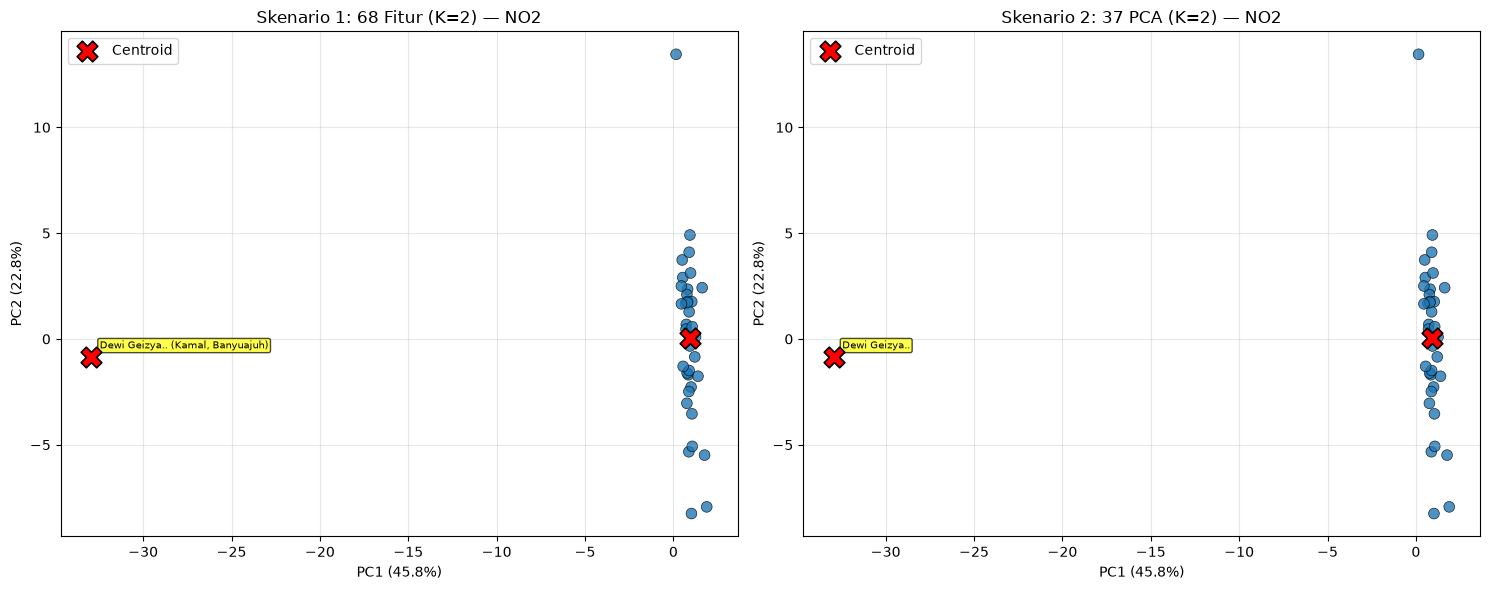

Tersimpan: fig_no2_cluster_68.png


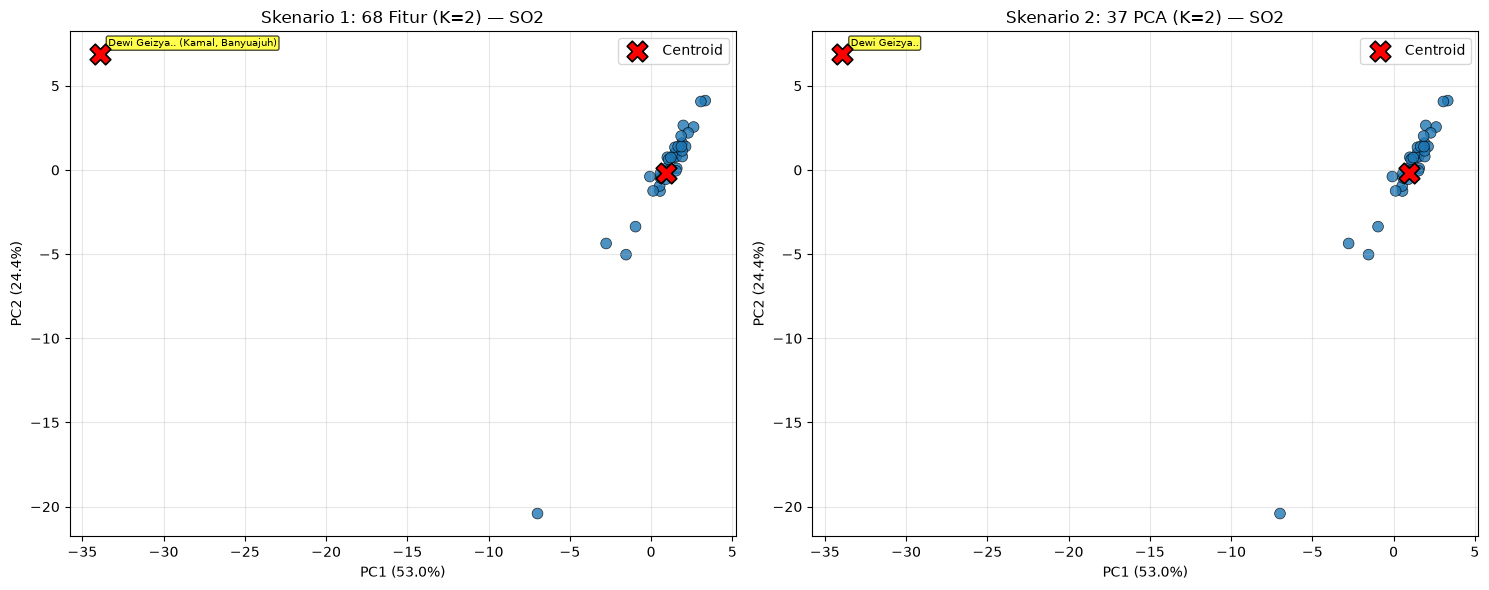

Tersimpan: fig_so2_cluster_68.png


In [9]:
for p in POLLUTANTS:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    best_k_68 = results_68[p]['best_k']
    best_k_pca = results_pca[p]['best_k']
    labels_68 = labels_dict[p]['labels_68']
    labels_pca = labels_dict[p]['labels_pca']
    km_68 = km_models[p]['km_68']
    km_pca = km_models[p]['km_pca']
    
    # Muat metadata nama/daerah untuk anotasi outlier
    df_meta = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv', usecols=META_COLS)
    
    # Proyeksikan data + centroid ke 2D untuk visualisasi
    pca_2d = PCA(n_components=2)
    X_68_2d = pca_2d.fit_transform(X_scaled_dict[p])
    C_68_2d = pca_2d.transform(km_68.cluster_centers_)
    pca_2d_b = PCA(n_components=2)
    X_pca_2d = pca_2d_b.fit_transform(X_pca_dict[p])
    C_pca_2d = pca_2d_b.transform(km_pca.cluster_centers_)
    
    # Skenario 1 — dengan centroid (X merah) + anotasi anggota cluster minoritas
    scatter1 = ax1.scatter(X_68_2d[:, 0], X_68_2d[:, 1], c=labels_68, cmap='tab10', s=60, alpha=0.8, edgecolors='k', linewidths=0.5)
    ax1.scatter(C_68_2d[:, 0], C_68_2d[:, 1], c='red', marker='X', s=220, edgecolors='black', linewidths=1.2, label='Centroid', zorder=5)
    ax1.set_title(f'Skenario 1: 68 Fitur (K={best_k_68}) — {p}')
    ax1.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
    ax1.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # Anotasi cluster kecil (outlier): tandai nama/daerahnya
    vals, cnts = np.unique(labels_68, return_counts=True)
    minor = vals[np.argmin(cnts)]
    for i in np.where(labels_68 == minor)[0]:
        ax1.annotate(f"{df_meta.iloc[i]['nama'][:14]}.. ({df_meta.iloc[i]['daerah']})", (X_68_2d[i,0], X_68_2d[i,1]), fontsize=7, xytext=(6,6), textcoords='offset points', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7))
    
    # Skenario 2 — dengan centroid + anotasi
    scatter2 = ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_pca, cmap='tab10', s=60, alpha=0.8, edgecolors='k', linewidths=0.5)
    ax2.scatter(C_pca_2d[:, 0], C_pca_2d[:, 1], c='red', marker='X', s=220, edgecolors='black', linewidths=1.2, label='Centroid', zorder=5)
    ax2.set_title(f'Skenario 2: 37 PCA (K={best_k_pca}) — {p}')
    ax2.set_xlabel(f"PC1 ({pca_2d_b.explained_variance_ratio_[0]*100:.1f}%)")
    ax2.set_ylabel(f"PC2 ({pca_2d_b.explained_variance_ratio_[1]*100:.1f}%)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    vals2, cnts2 = np.unique(labels_pca, return_counts=True)
    minor2 = vals2[np.argmin(cnts2)]
    for i in np.where(labels_pca == minor2)[0][:5]:
        ax2.annotate(f"{df_meta.iloc[i]['nama'][:14]}..", (X_pca_2d[i,0], X_pca_2d[i,1]), fontsize=7, xytext=(6,6), textcoords='offset points', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_cluster_68.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: fig_{p.lower()}_cluster_68.png')

## 5.2.6 Silhouette per Sampel (Diagram Silhouette)

Rata-rata silhouette saja bisa menipu (misal K=2 dengan komposisi 36-vs-1). Diagram ini menampilkan **silhouette tiap titik**, diurutkan per cluster — terlihat apakah ada cluster yang tipis/outlier atau semua anggota kompak.

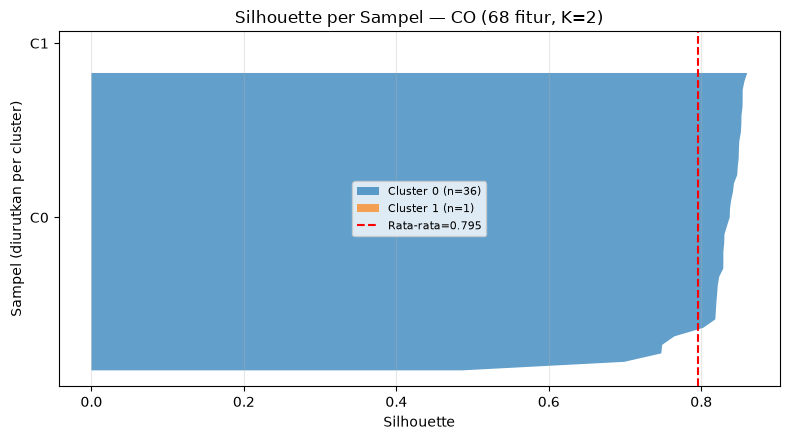

Tersimpan: fig_co_silhouette_samples.png


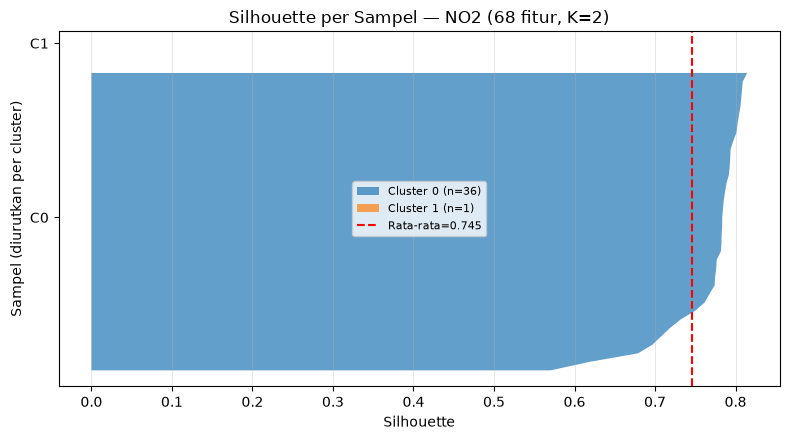

Tersimpan: fig_no2_silhouette_samples.png


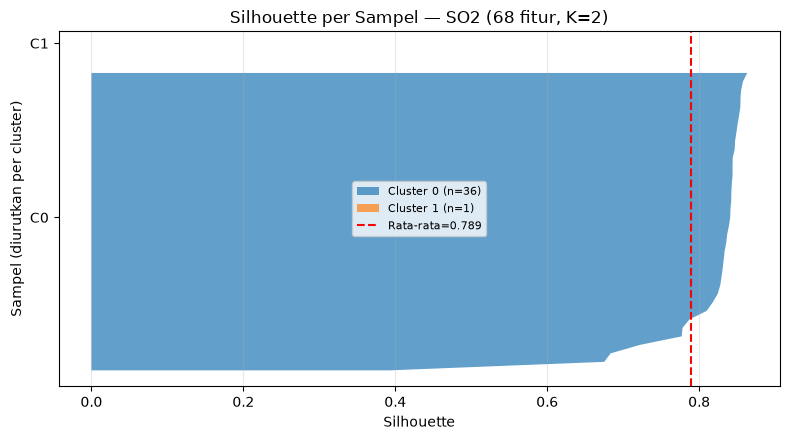

Tersimpan: fig_so2_silhouette_samples.png


In [10]:
for p in POLLUTANTS:
    X = X_scaled_dict[p]
    labels = labels_dict[p]['labels_68']
    k = results_68[p]['best_k']
    sil_vals = silhouette_samples(X, labels)
    sil_avg = results_68[p]['best_sil']
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    y_lower = 0
    yticks = []
    for c in range(k):
        c_vals = np.sort(sil_vals[labels == c])
        y_upper = y_lower + len(c_vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals, alpha=0.7, label=f'Cluster {c} (n={len(c_vals)})')
        yticks.append((y_lower + y_upper) / 2)
        y_lower = y_upper + 2
    ax.axvline(sil_avg, color='red', linestyle='--', label=f'Rata-rata={sil_avg:.3f}')
    ax.set_title(f'Silhouette per Sampel — {p} (68 fitur, K={k})')
    ax.set_xlabel('Silhouette')
    ax.set_ylabel('Sampel (diurutkan per cluster)')
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'C{c}' for c in range(k)])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_silhouette_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: fig_{p.lower()}_silhouette_samples.png')

## 5.2.7 Distribusi Ukuran Cluster & Komposisi Daerah

Menjawab dua pertanyaan penting: (1) apakah ukuran cluster seimbang atau didominasi outlier 36-vs-1, dan (2) apakah cluster berkaitan dengan **daerah** (interpretasi spasial).

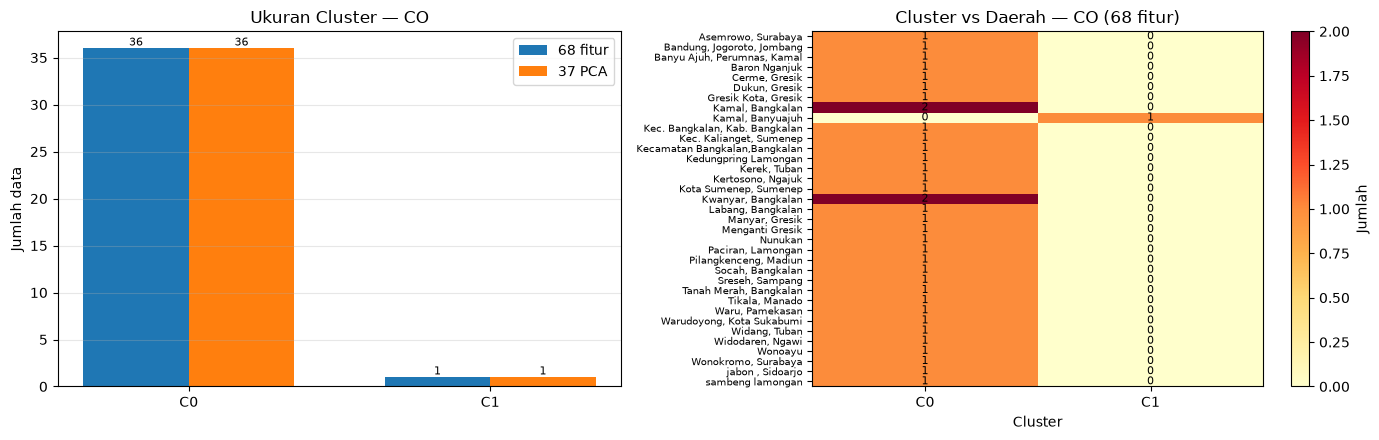

--- CO crosstab cluster vs daerah ---
col_0                           0  1
daerah                              
Asemrowo, Surabaya              1  0
Bandung, Jogoroto, Jombang      1  0
Banyu Ajuh, Perumnas, Kamal     1  0
Baron Nganjuk                   1  0
Cerme, Gresik                   1  0
Dukun, Gresik                   1  0
Gresik Kota, Gresik             1  0
Kamal, Bangkalan                2  0
Kamal, Banyuajuh                0  1
Kec. Bangkalan, Kab. Bangkalan  1  0
Kec. Kalianget, Sumenep         1  0
Kecamatan Bangkalan,Bangkalan   1  0
Kedungpring Lamongan            1  0
Kerek, Tuban                    1  0
Kertosono, Ngajuk               1  0
Kota Sumenep, Sumenep           1  0
Kwanyar, Bangkalan              2  0
Labang, Bangkalan               1  0
Manyar, Gresik                  1  0
Menganti Gresik                 1  0
Nunukan                         1  0
Paciran, Lamongan               1  0
Pilangkenceng, Madiun           1  0
Socah, Bangkalan                1  0


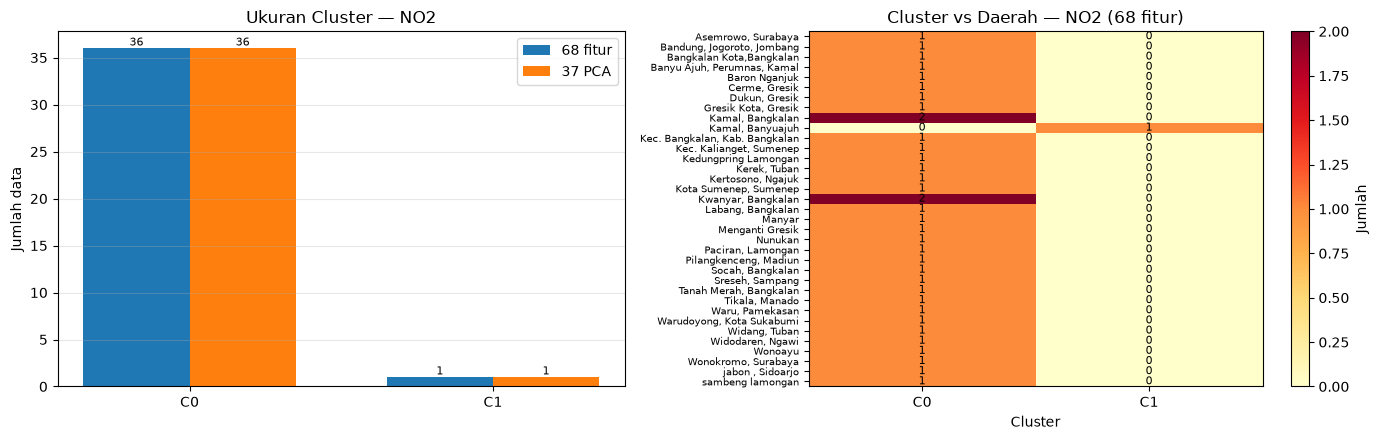

--- NO2 crosstab cluster vs daerah ---
col_0                           0  1
daerah                              
Asemrowo, Surabaya              1  0
Bandung, Jogoroto, Jombang      1  0
Bangkalan Kota,Bangkalan        1  0
Banyu Ajuh, Perumnas, Kamal     1  0
Baron Nganjuk                   1  0
Cerme, Gresik                   1  0
Dukun, Gresik                   1  0
Gresik Kota, Gresik             1  0
Kamal, Bangkalan                2  0
Kamal, Banyuajuh                0  1
Kec. Bangkalan, Kab. Bangkalan  1  0
Kec. Kalianget, Sumenep         1  0
Kedungpring Lamongan            1  0
Kerek, Tuban                    1  0
Kertosono, Ngajuk               1  0
Kota Sumenep, Sumenep           1  0
Kwanyar, Bangkalan              2  0
Labang, Bangkalan               1  0
Manyar                          1  0
Menganti Gresik                 1  0
Nunukan                         1  0
Paciran, Lamongan               1  0
Pilangkenceng, Madiun           1  0
Socah, Bangkalan                1  0

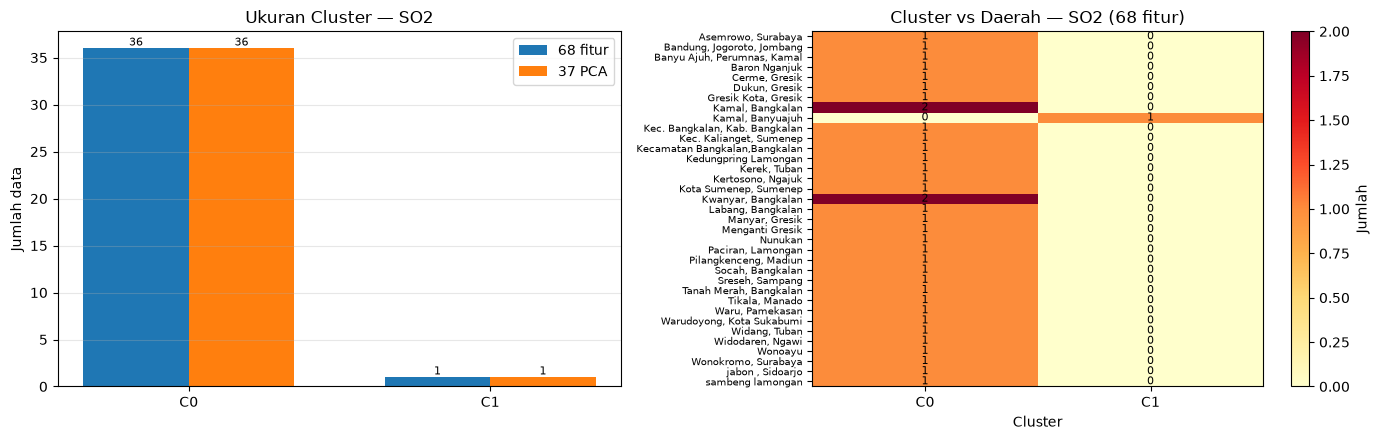

--- SO2 crosstab cluster vs daerah ---
col_0                           0  1
daerah                              
Asemrowo, Surabaya              1  0
Bandung, Jogoroto, Jombang      1  0
Banyu Ajuh, Perumnas, Kamal     1  0
Baron Nganjuk                   1  0
Cerme, Gresik                   1  0
Dukun, Gresik                   1  0
Gresik Kota, Gresik             1  0
Kamal, Bangkalan                2  0
Kamal, Banyuajuh                0  1
Kec. Bangkalan, Kab. Bangkalan  1  0
Kec. Kalianget, Sumenep         1  0
Kecamatan Bangkalan,Bangkalan   1  0
Kedungpring Lamongan            1  0
Kerek, Tuban                    1  0
Kertosono, Ngajuk               1  0
Kota Sumenep, Sumenep           1  0
Kwanyar, Bangkalan              2  0
Labang, Bangkalan               1  0
Manyar, Gresik                  1  0
Menganti Gresik                 1  0
Nunukan                         1  0
Paciran, Lamongan               1  0
Pilangkenceng, Madiun           1  0
Socah, Bangkalan                1  0

In [11]:
for p in POLLUTANTS:
    df_meta = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv', usecols=META_COLS)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
    
    # (a) Bar ukuran cluster: Skenario 1 vs 2
    labels_68 = labels_dict[p]['labels_68']
    labels_pca = labels_dict[p]['labels_pca']
    u68, c68 = np.unique(labels_68, return_counts=True)
    upca, cpca = np.unique(labels_pca, return_counts=True)
    x = np.arange(max(len(u68), len(upca)))
    w = 0.35
    b1 = ax1.bar(x[:len(u68)] - w/2, c68, width=w, label='68 fitur')
    b2 = ax1.bar(x[:len(upca)] + w/2, cpca, width=w, label='37 PCA')
    ax1.bar_label(b1, fontsize=8)
    ax1.bar_label(b2, fontsize=8)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'C{i}' for i in x])
    ax1.set_title(f'Ukuran Cluster — {p}')
    ax1.set_ylabel('Jumlah data')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # (b) Heatmap cluster vs daerah (Skenario 1)
    ct = pd.crosstab(df_meta['daerah'], labels_68)
    im = ax2.imshow(ct.values, aspect='auto', cmap='YlOrRd')
    ax2.set_xticks(range(len(ct.columns)))
    ax2.set_xticklabels([f'C{c}' for c in ct.columns])
    ax2.set_yticks(range(len(ct.index)))
    ax2.set_yticklabels(list(ct.index), fontsize=7)
    ax2.set_title(f'Cluster vs Daerah — {p} (68 fitur)')
    ax2.set_xlabel('Cluster')
    for i in range(len(ct.index)):
        for j in range(len(ct.columns)):
            ax2.text(j, i, ct.values[i, j], ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax2, label='Jumlah')
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_cluster_sizes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'--- {p} crosstab cluster vs daerah ---')
    print(ct.to_string())
    print(f"Tersimpan: fig_{p.lower()}_cluster_sizes.png")

## 5.2.8 Profil Centroid & Fitur Pembeda

(a) **Heatmap centroid** menunjukkan rata-rata tiap fitur (terstandarisasi) per cluster. (b) **Bar selisih centroid** menampilkan 10 fitur dengan perbedaan terbesar — inilah ciri yang membedakan kedua cluster.

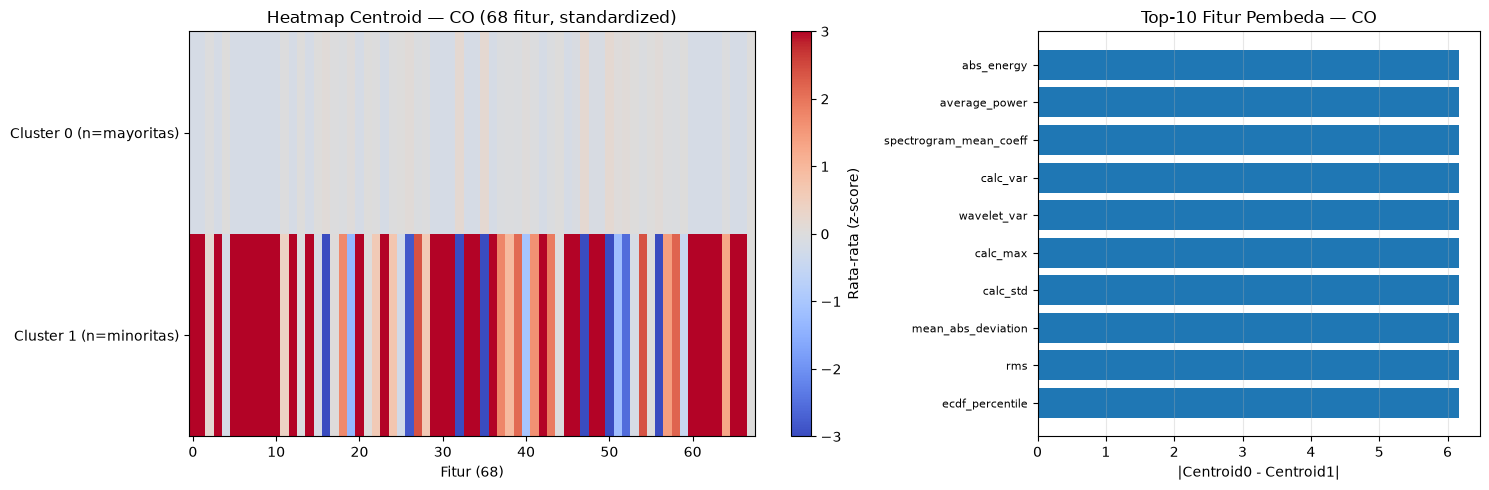

CO Top-5 pembeda: ['abs_energy', 'average_power', 'spectrogram_mean_coeff', 'calc_var', 'wavelet_var']
Tersimpan: fig_co_centroid_profile.png


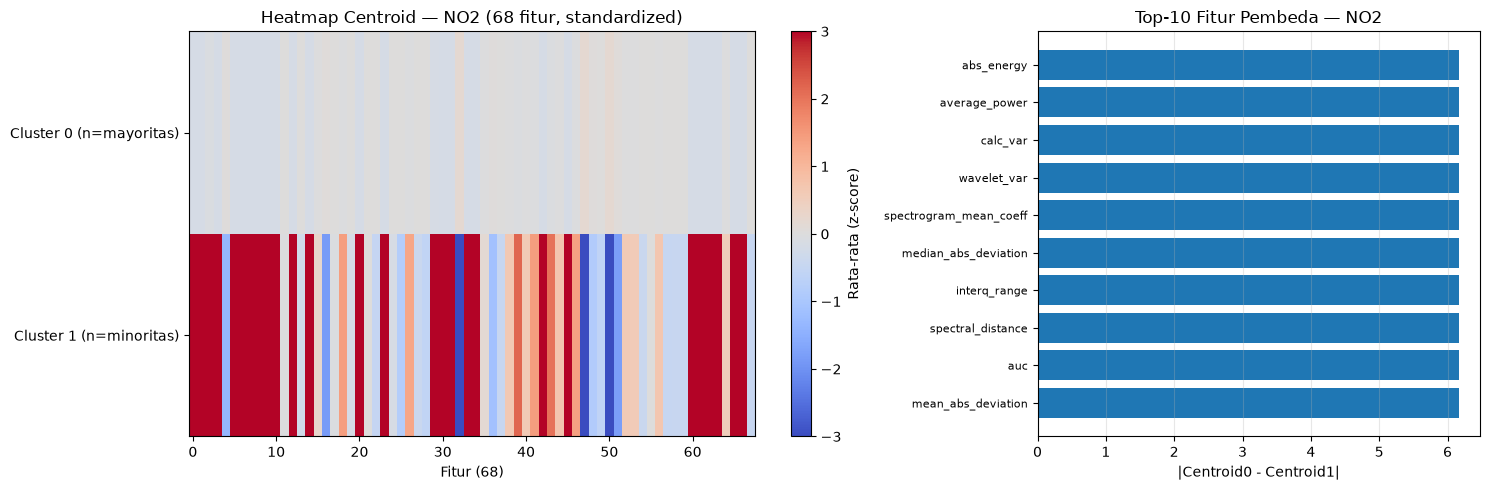

NO2 Top-5 pembeda: ['abs_energy', 'average_power', 'calc_var', 'wavelet_var', 'spectrogram_mean_coeff']
Tersimpan: fig_no2_centroid_profile.png


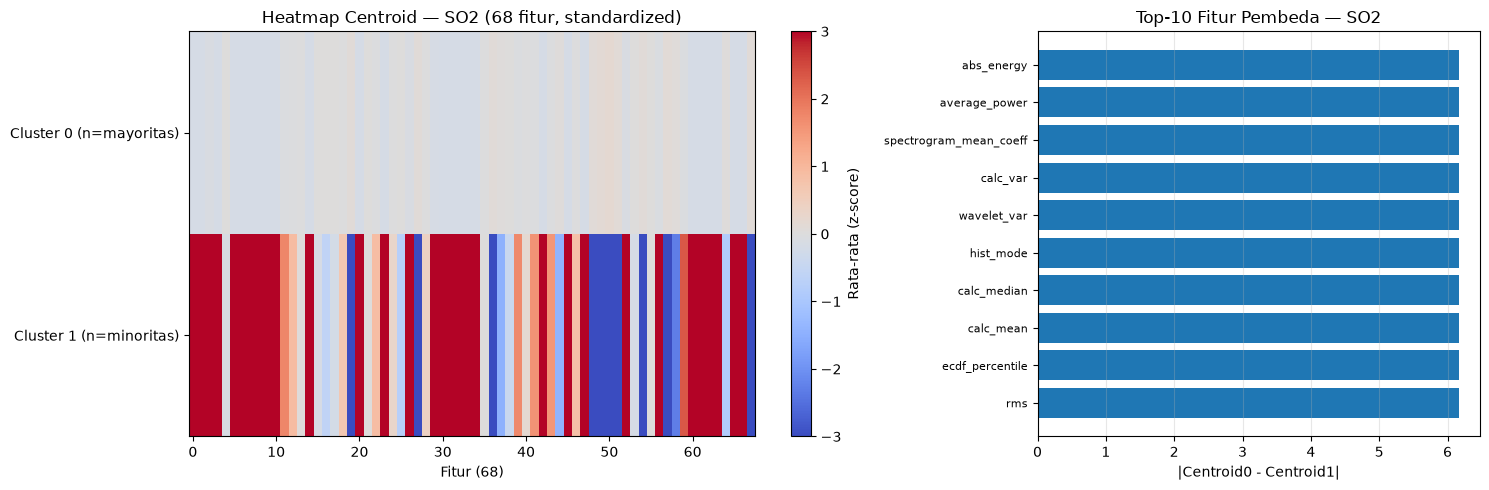

SO2 Top-5 pembeda: ['abs_energy', 'average_power', 'spectrogram_mean_coeff', 'calc_var', 'wavelet_var']
Tersimpan: fig_so2_centroid_profile.png


In [12]:
for p in POLLUTANTS:
    cols = [c for c in pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv', nrows=0).columns if c not in META_COLS]
    km = km_models[p]['km_68']
    C = km.cluster_centers_  # (K, 68), sudah dalam skala standardized
    diff = np.abs(C[0] - C[1])
    top10_idx = np.argsort(diff)[::-1][:10]
    top10_names = [cols[i] for i in top10_idx]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.6, 1]})
    
    # (a) Heatmap centroid
    im = ax1.imshow(C, aspect='auto', cmap='coolwarm', vmin=-3, vmax=3)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Cluster 0 (n=mayoritas)', 'Cluster 1 (n=minoritas)'])
    ax1.set_xlabel('Fitur (68)')
    ax1.set_title(f'Heatmap Centroid — {p} (68 fitur, standardized)')
    plt.colorbar(im, ax=ax1, label='Rata-rata (z-score)')
    
    # (b) Top-10 fitur pembeda
    y = np.arange(10)
    ax2.barh(y, diff[top10_idx])
    ax2.set_yticks(y)
    ax2.set_yticklabels(top10_names, fontsize=8)
    ax2.invert_yaxis()
    ax2.set_xlabel('|Centroid0 - Centroid1|')
    ax2.set_title(f'Top-10 Fitur Pembeda — {p}')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_centroid_profile.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{p} Top-5 pembeda: {top10_names[:5]}')
    print(f"Tersimpan: fig_{p.lower()}_centroid_profile.png")

## 5.2.9 Jarak ke Centroid & Sebaran Fitur Pembeda

(a) **Histogram jarak ke centroid** membuktikan apakah cluster minoritas (1 data) adalah outlier jauh. (b) **Boxplot** 4 fitur pembeda utama memperlihatkan sebaran tiap cluster secara individual.

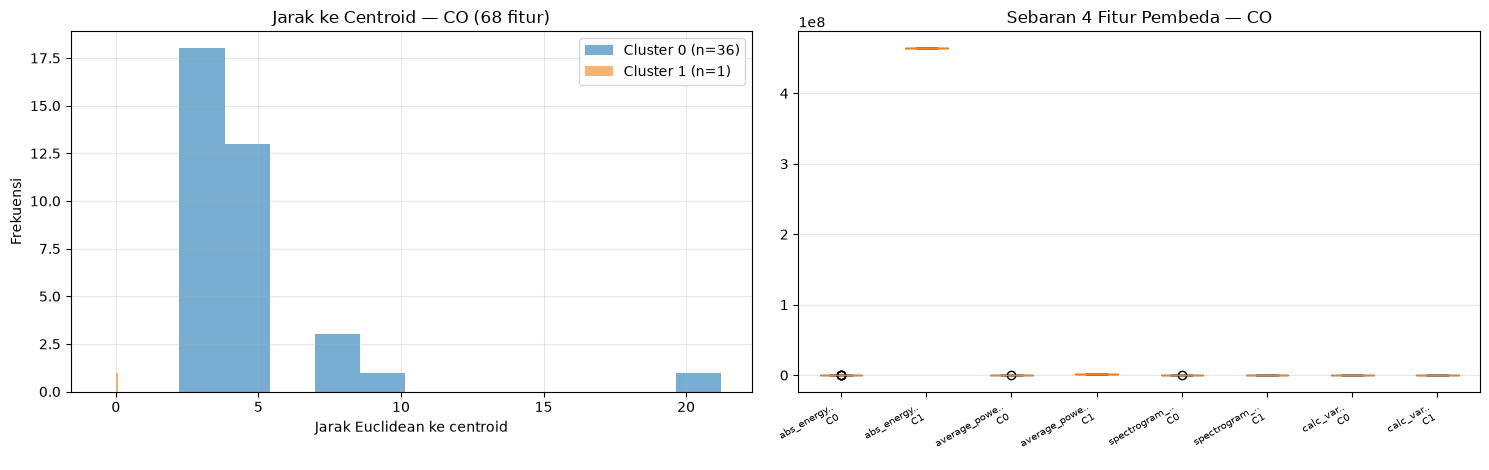

Tersimpan: fig_co_distance_boxplot.png


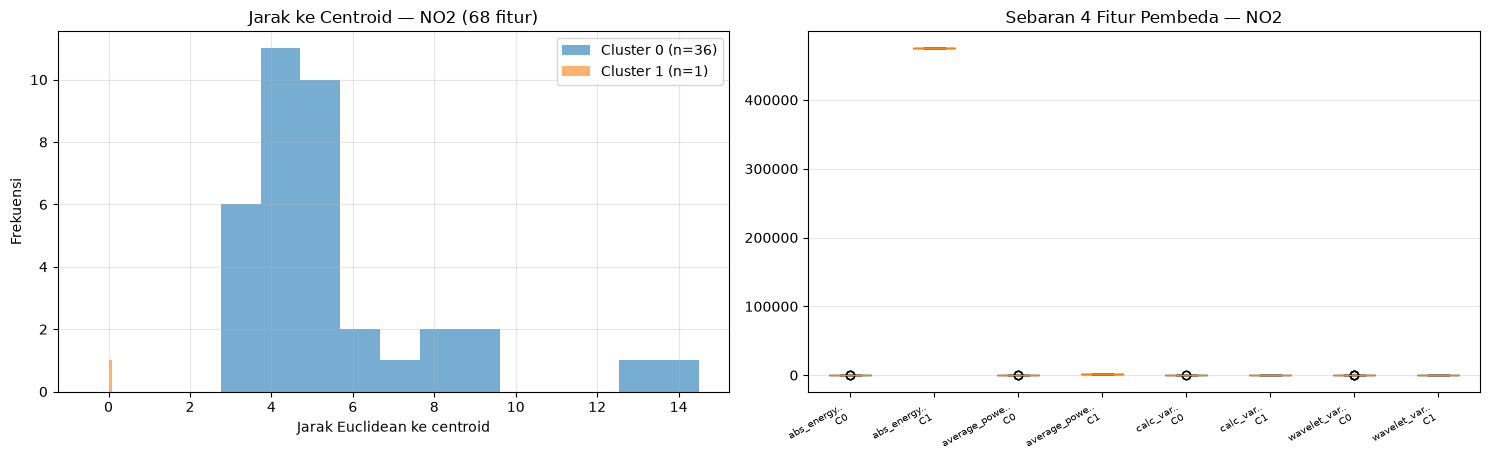

Tersimpan: fig_no2_distance_boxplot.png


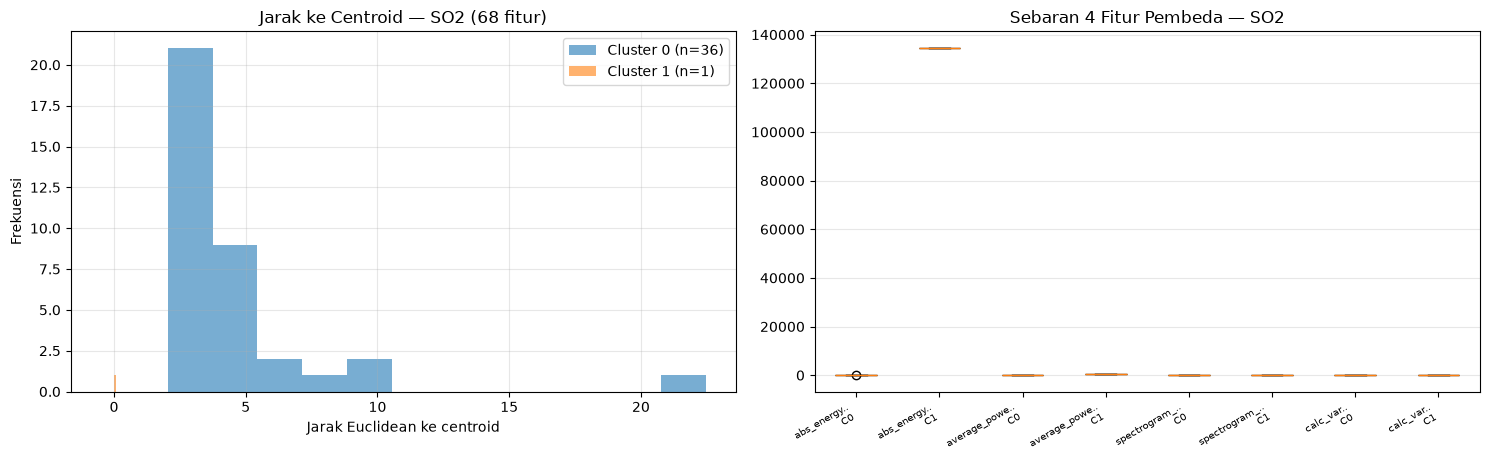

Tersimpan: fig_so2_distance_boxplot.png


In [13]:
for p in POLLUTANTS:
    df_full = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv')
    feat_cols = [c for c in df_full.columns if c not in META_COLS]
    X = X_scaled_dict[p]
    labels = labels_dict[p]['labels_68']
    km = km_models[p]['km_68']
    # Jarak Euclidean tiap titik ke centroid cluster-nya
    dists = np.linalg.norm(X - km.cluster_centers_[labels], axis=1)
    
    # Cari 4 fitur pembeda dari selisih centroid
    diff = np.abs(km.cluster_centers_[0] - km.cluster_centers_[1])
    top4_idx = np.argsort(diff)[::-1][:4]
    top4 = [feat_cols[i] for i in top4_idx]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.8))
    
    # (a) Histogram jarak per cluster
    for c in [0, 1]:
        ax1.hist(dists[labels == c], bins=12, alpha=0.6, label=f'Cluster {c} (n={(labels==c).sum()})')
    ax1.set_title(f'Jarak ke Centroid — {p} (68 fitur)')
    ax1.set_xlabel('Jarak Euclidean ke centroid')
    ax1.set_ylabel('Frekuensi')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # (b) Boxplot 4 fitur pembeda, dikelompokkan per cluster
    data_box = []
    tick_labels = []
    for f in top4:
        for c in [0, 1]:
            data_box.append(df_full.loc[labels == c, f].values)
            tick_labels.append(f'{f[:12]}..\nC{c}')
    bp = ax2.boxplot(data_box, patch_artist=True)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor('lightblue' if i % 2 == 0 else 'salmon')
    ax2.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=7)
    ax2.set_title(f'Sebaran 4 Fitur Pembeda — {p}')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_distance_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Tersimpan: fig_{p.lower()}_distance_boxplot.png")

## 5.2.10 Ringkasan Metrik per Polutan

| Polutan | Skenario | Fitur | K Terbaik | Silhouette Score | Inertia |
|---------|----------|-------|-----------|------------------|---------|
| CO | 1 | 68 | 2 | 0.7955 | 1123.80 |
| CO | 2 | 37 PCA | 2 | 0.7955 | 1123.80 |
| NO₂ | 1 | 68 | 2 | 0.7455 | 1326.58 |
| NO₂ | 2 | 37 PCA | 2 | 0.7455 | 1326.58 |
| SO₂ | 1 | 68 | 2 | 0.7894 | 1210.46 |
| SO₂ | 2 | 37 PCA | 2 | 0.7894 | 1210.46 |

In [14]:
rows = []
for p in POLLUTANTS:
    best_k_68 = results_68[p]['best_k']
    best_sil_68 = results_68[p]['best_sil']
    inertia_68 = results_68[p]['inertias'][best_k_68 - 2]
    
    best_k_pca = results_pca[p]['best_k']
    best_sil_pca = results_pca[p]['best_sil']
    inertia_pca = results_pca[p]['inertias'][best_k_pca - 2]
    
    rows.append({'Polutan': p, 'Skenario': '1 (68 Fitur)', 'Fitur': 68,
                 'K Terbaik': best_k_68, 'Silhouette': round(best_sil_68, 4),
                 'Inertia': round(inertia_68, 2)})
    rows.append({'Polutan': p, 'Skenario': '2 (37 PCA)', 'Fitur': 37,
                 'K Terbaik': best_k_pca, 'Silhouette': round(best_sil_pca, 4),
                 'Inertia': round(inertia_pca, 2)})

df_ringkasan = pd.DataFrame(rows)
df_ringkasan

,Polutan,Skenario,Fitur,K Terbaik,Silhouette,Inertia
0,CO,1 (68 Fitur),68,2,0.7955,1123.80
1,CO,2 (37 PCA),37,2,0.7955,1123.80
2,NO2,1 (68 Fitur),68,2,0.7455,1326.58
3,NO2,2 (37 PCA),37,2,0.7455,1326.58
4,SO2,1 (68 Fitur),68,2,0.7894,1210.46
5,SO2,2 (37 PCA),37,2,0.7894,1210.46


## 5.2.11 Analisis Sensitivitas: K-Means Tanpa Outlier

Hasil 5.2.4–5.2.9 menunjukkan K=2 selalu beranggotakan 36-vs-1 (satu sampel dari `Kamal, Banyuajuh`). Pada bagian ini sampel outlier tersebut **dikeluarkan** (tersisa 36 data), lalu pencarian K optimal (Elbow + Silhouette, K=2..10) dan clustering diulang pada 68 fitur yang di-*scaling* ulang — untuk melihat struktur cluster yang sebenarnya tanpa dominasi outlier.

In [15]:
sens_results = {}
for p in POLLUTANTS:
    df_full = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv')
    feat_cols = [c for c in df_full.columns if c not in META_COLS]
    X_full = df_full[feat_cols].values
    if np.isnan(X_full).sum() > 0:
        X_full = SimpleImputer(strategy='median').fit_transform(X_full)
    
    # Identifikasi outlier = anggota cluster minoritas Skenario 1
    labels = labels_dict[p]['labels_68']
    vals, cnts = np.unique(labels, return_counts=True)
    minor = vals[np.argmin(cnts)]
    out_idx = np.where(labels == minor)[0]
    for i in out_idx:
        print(f"{p} outlier: index={i}, nama={df_full.iloc[i]['nama']}, daerah={df_full.iloc[i]['daerah']}")
    
    # Keluarkan outlier, scaling ulang pada 36 data
    mask = np.ones(len(X_full), dtype=bool)
    mask[out_idx] = False
    Xs36 = StandardScaler().fit_transform(X_full[mask])
    print(f'--- {p} tanpa outlier: {Xs36.shape[0]} data x {Xs36.shape[1]} fitur ---')
    inertias, silhouettes, best_k, best_sil = find_optimal_k(Xs36, f'{p}-noOut')
    sens_results[p] = {'X': Xs36, 'mask': mask, 'out_idx': out_idx,
                       'inertias': inertias, 'silhouettes': silhouettes,
                       'best_k': best_k, 'best_sil': best_sil}
    print(f'>>> {p} tanpa outlier: K={best_k}, silhouette={best_sil:.4f}')

CO outlier: index=36, nama=Dewi Geizya, daerah=Kamal, Banyuajuh
--- CO tanpa outlier: 36 data x 68 fitur ---
  CO-noOut K=2: inertia=1542.72, silhouette=0.6737
  CO-noOut K=3: inertia=1232.57, silhouette=0.1868
  CO-noOut K=4: inertia=1045.07, silhouette=0.2236


  CO-noOut K=5: inertia=933.51, silhouette=0.1404
  CO-noOut K=6: inertia=798.35, silhouette=0.1390


  CO-noOut K=7: inertia=660.89, silhouette=0.1494
  CO-noOut K=8: inertia=589.16, silhouette=0.1413
  CO-noOut K=9: inertia=531.27, silhouette=0.1432
  CO-noOut K=10: inertia=491.91, silhouette=0.1337
>>> CO tanpa outlier: K=2, silhouette=0.6737
NO2 outlier: index=36, nama=Dewi Geizya, daerah=Kamal, Banyuajuh
--- NO2 tanpa outlier: 36 data x 68 fitur ---


  NO2-noOut K=2: inertia=1767.79, silhouette=0.3992
  NO2-noOut K=3: inertia=1414.89, silhouette=0.1794


  NO2-noOut K=4: inertia=1227.44, silhouette=0.1583
  NO2-noOut K=5: inertia=1077.06, silhouette=0.1631
  NO2-noOut K=6: inertia=990.35, silhouette=0.1288


...

  NO2-noOut K=10: inertia=557.72, silhouette=0.1542
>>> NO2 tanpa outlier: K=2, silhouette=0.3992
SO2 outlier: index=36, nama=Dewi Geizya, daerah=Kamal, Banyuajuh
--- SO2 tanpa outlier: 36 data x 68 fitur ---
  SO2-noOut K=2: inertia=1655.31, silhouette=0.6501


  SO2-noOut K=3: inertia=1203.34, silhouette=0.2248
  SO2-noOut K=4: inertia=965.43, silhouette=0.2641


  SO2-noOut K=5: inertia=860.13, silhouette=0.2199
  SO2-noOut K=6: inertia=726.03, silhouette=0.1404
  SO2-noOut K=7: inertia=654.08, silhouette=0.1274
  SO2-noOut K=8: inertia=556.84, silhouette=0.1239


  SO2-noOut K=9: inertia=512.87, silhouette=0.1188


  SO2-noOut K=10: inertia=460.61, silhouette=0.1341
>>> SO2 tanpa outlier: K=2, silhouette=0.6501


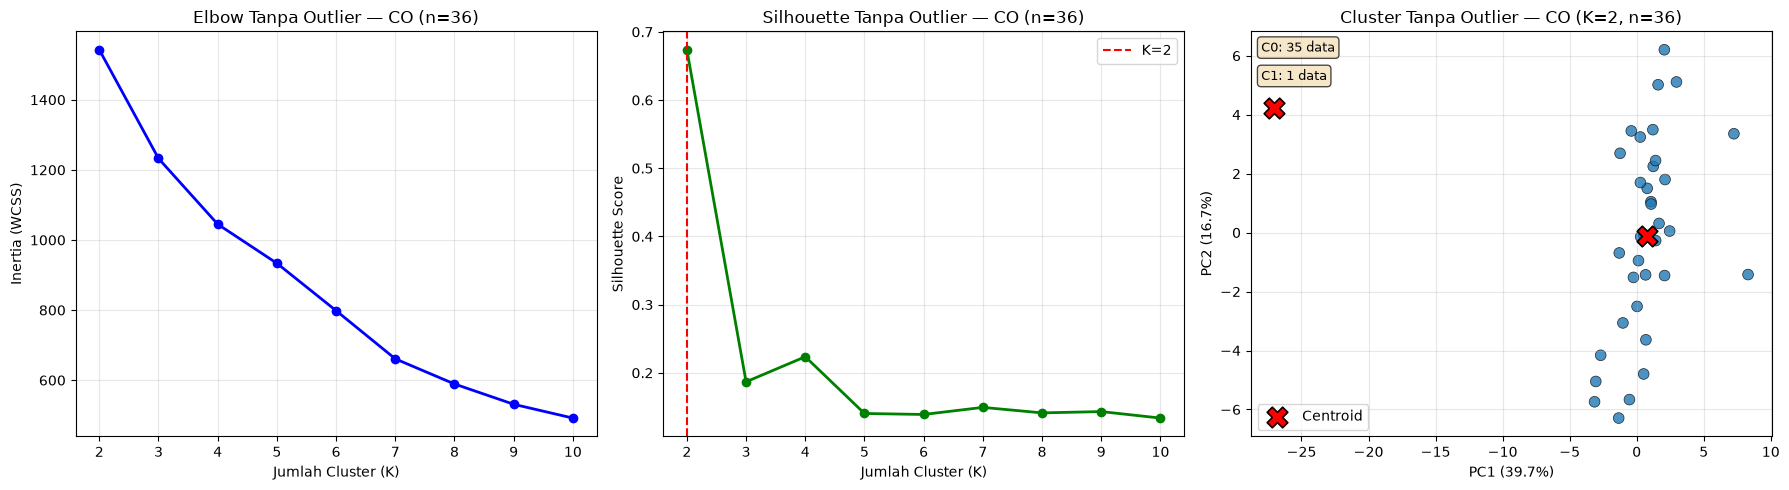

Tersimpan: fig_co_sensitivity_no_outlier.png


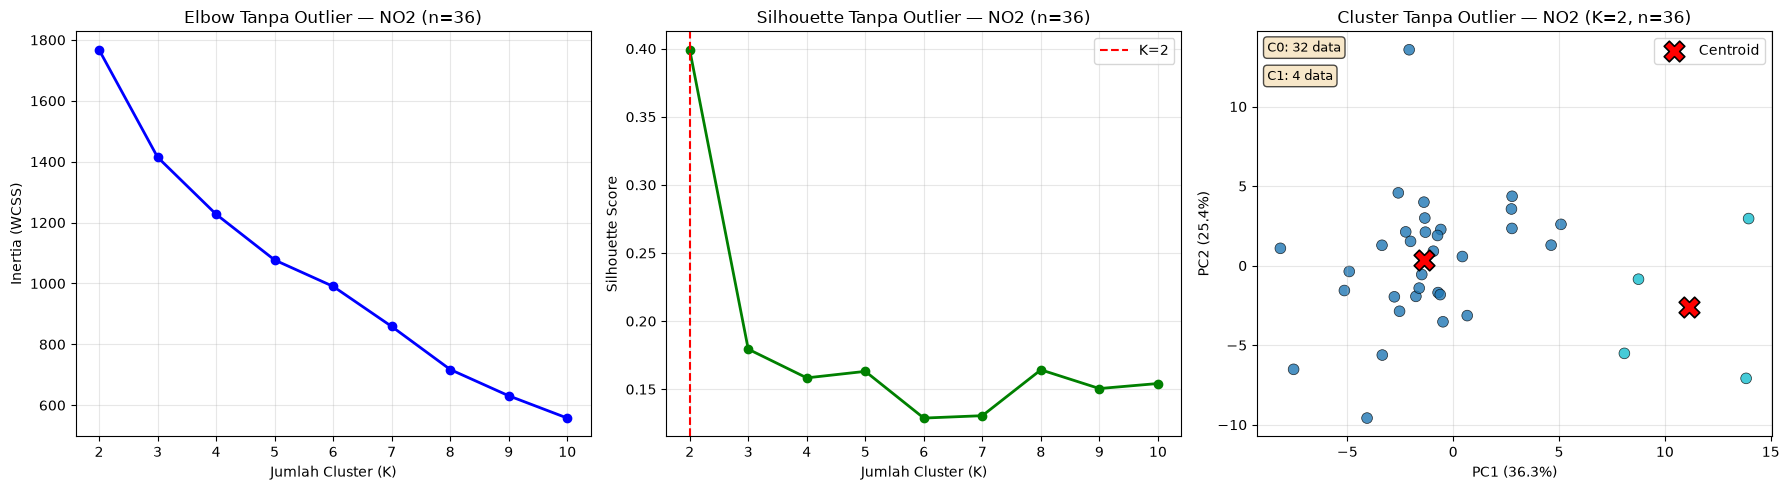

Tersimpan: fig_no2_sensitivity_no_outlier.png


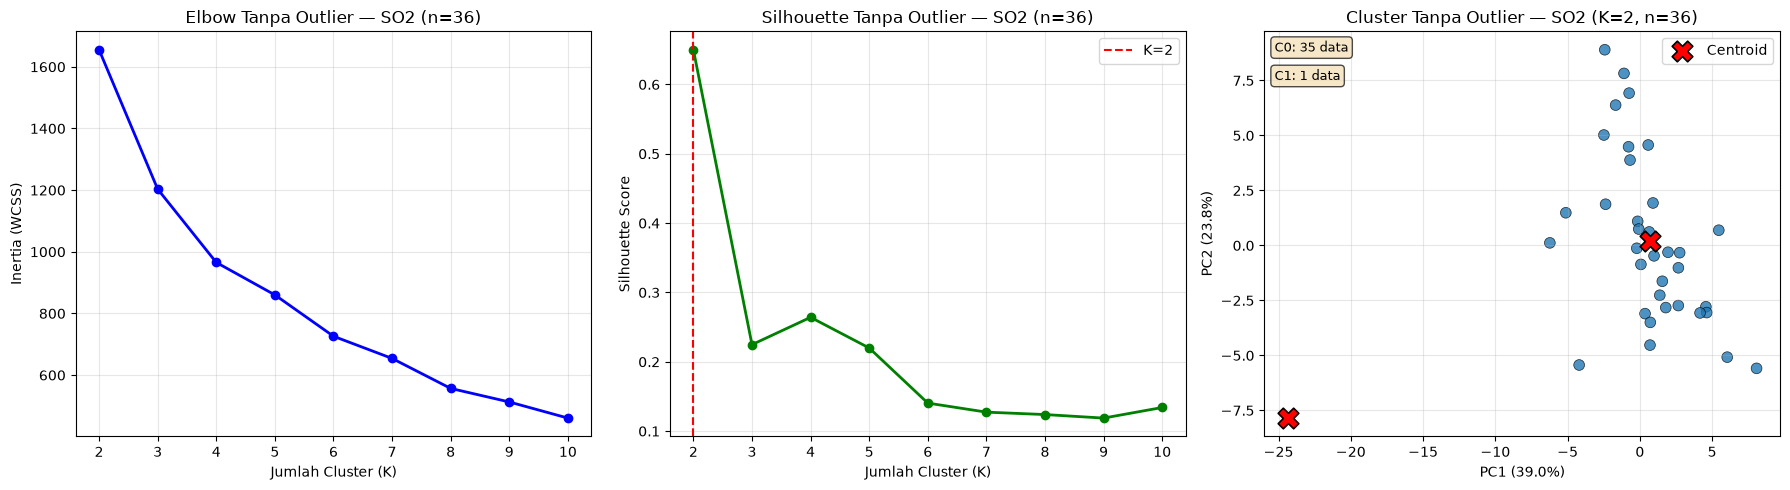

Tersimpan: fig_so2_sensitivity_no_outlier.png


In [16]:
for p in POLLUTANTS:
    r = sens_results[p]
    Xs36, best_k = r['X'], r['best_k']
    km_s = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    lb_s = km_s.fit_predict(Xs36)
    r['labels'] = lb_s
    r['km'] = km_s
    
    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5))
    
    ax0.plot(list(K_range), r['inertias'], 'bo-', linewidth=2)
    ax0.set_xlabel('Jumlah Cluster (K)')
    ax0.set_ylabel('Inertia (WCSS)')
    ax0.set_title(f'Elbow Tanpa Outlier — {p} (n=36)')
    ax0.grid(True, alpha=0.3)
    
    ax1.plot(list(K_range), r['silhouettes'], 'go-', linewidth=2)
    ax1.axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
    ax1.set_xlabel('Jumlah Cluster (K)')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title(f'Silhouette Tanpa Outlier — {p} (n=36)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    pca_v = PCA(n_components=2)
    Xv = pca_v.fit_transform(Xs36)
    Cv = pca_v.transform(km_s.cluster_centers_)
    ax2.scatter(Xv[:, 0], Xv[:, 1], c=lb_s, cmap='tab10', s=60, alpha=0.8, edgecolors='k', linewidths=0.5)
    ax2.scatter(Cv[:, 0], Cv[:, 1], c='red', marker='X', s=220, edgecolors='black', linewidths=1.2, label='Centroid', zorder=5)
    ax2.set_xlabel(f"PC1 ({pca_v.explained_variance_ratio_[0]*100:.1f}%)")
    ax2.set_ylabel(f"PC2 ({pca_v.explained_variance_ratio_[1]*100:.1f}%)")
    ax2.set_title(f'Cluster Tanpa Outlier — {p} (K={best_k}, n=36)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    for c in range(best_k):
        ax2.text(0.02, 0.95 - c*0.07, f'C{c}: {(lb_s==c).sum()} data', transform=ax2.transAxes, fontsize=9, bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_sensitivity_no_outlier.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Tersimpan: fig_{p.lower()}_sensitivity_no_outlier.png")

In [17]:
rows_sens = []
for p in POLLUTANTS:
    k0 = results_68[p]['best_k']
    rows_sens.append({'Polutan': p, 'Kondisi': 'Dengan outlier (n=37)',
                      'K Terbaik': k0, 'Silhouette': round(results_68[p]['best_sil'], 4),
                      'Inertia': round(results_68[p]['inertias'][k0 - 2], 2)})
    k1 = sens_results[p]['best_k']
    rows_sens.append({'Polutan': p, 'Kondisi': 'Tanpa outlier (n=36)',
                      'K Terbaik': k1, 'Silhouette': round(sens_results[p]['best_sil'], 4),
                      'Inertia': round(sens_results[p]['inertias'][k1 - 2], 2)})
df_sens = pd.DataFrame(rows_sens)
df_sens

,Polutan,Kondisi,K Terbaik,Silhouette,Inertia
0,CO,Dengan outlier (n=37),2,0.7955,1123.80
1,CO,Tanpa outlier (n=36),2,0.6737,1542.72
2,NO2,Dengan outlier (n=37),2,0.7455,1326.58
3,NO2,Tanpa outlier (n=36),2,0.3992,1767.79
4,SO2,Dengan outlier (n=37),2,0.7894,1210.46
5,SO2,Tanpa outlier (n=36),2,0.6501,1655.31


## 5.2.13 Kemiripan Antar Daerah: Daerah Mana yang Kondisinya Sama/Mirip?

Setiap sampel berasal dari suatu **daerah**. Untuk menjawab daerah mana yang kondisinya mirip, profil tiap daerah dihitung sebagai **rata-rata 68 fitur terstandarisasi** dari sampel-sampelnya, lalu:

(a) **Dendrogram (hierarchical clustering, metode Ward)** — daerah yang bercabang berdekatan berarti profil kondisinya mirip; warna cabang menunjukkan grup pada ambang jarak default.
(b) **Matriks jarak Euclidean antar daerah** — sel gelap = sangat mirip, sel terang = sangat berbeda.
(c) **Pemetaan daerah → cluster K-Means** — daerah dalam satu cluster dinyatakan memiliki kondisi yang sama; dilengkapi grafik jumlah daerah per cluster.

CO: 35 daerah unik dari 37 sampel


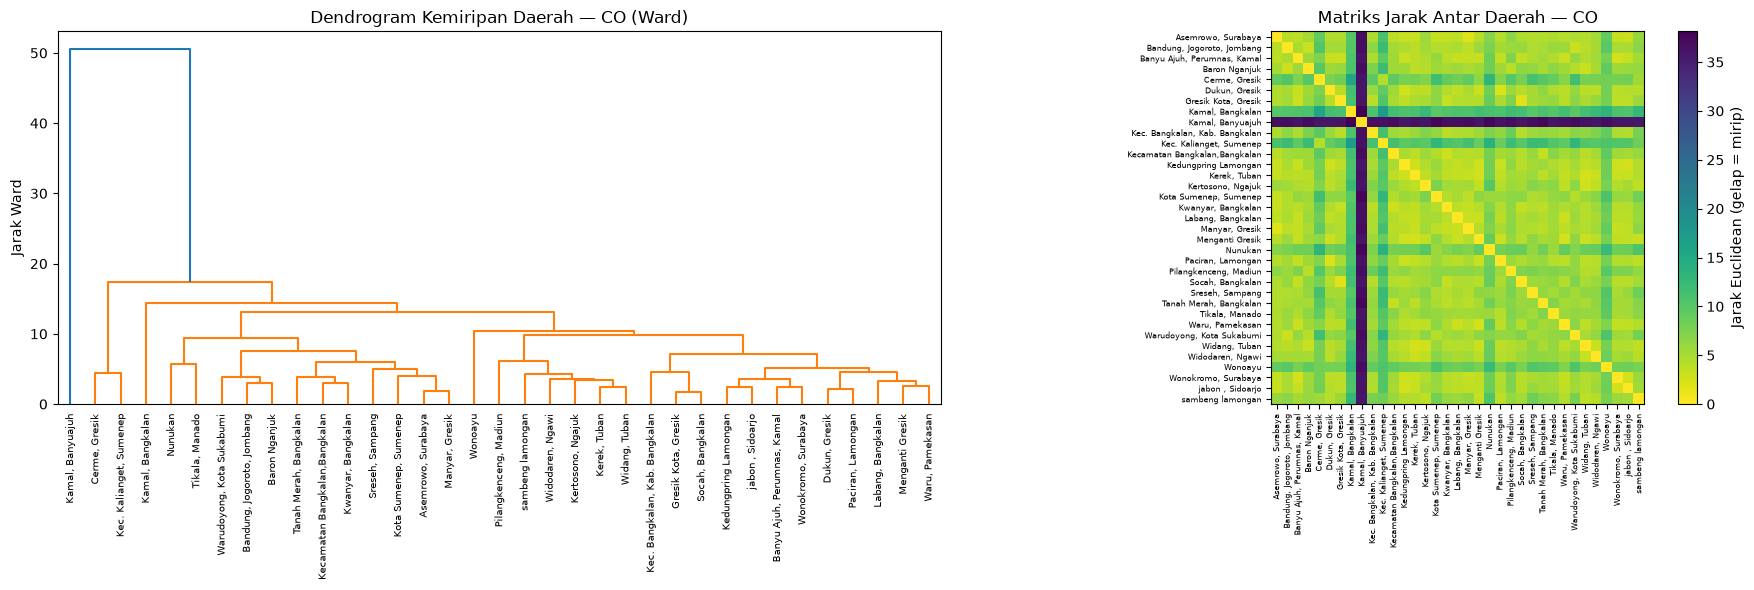

Tersimpan: fig_co_dendrogram_daerah.png
NO2: 35 daerah unik dari 37 sampel


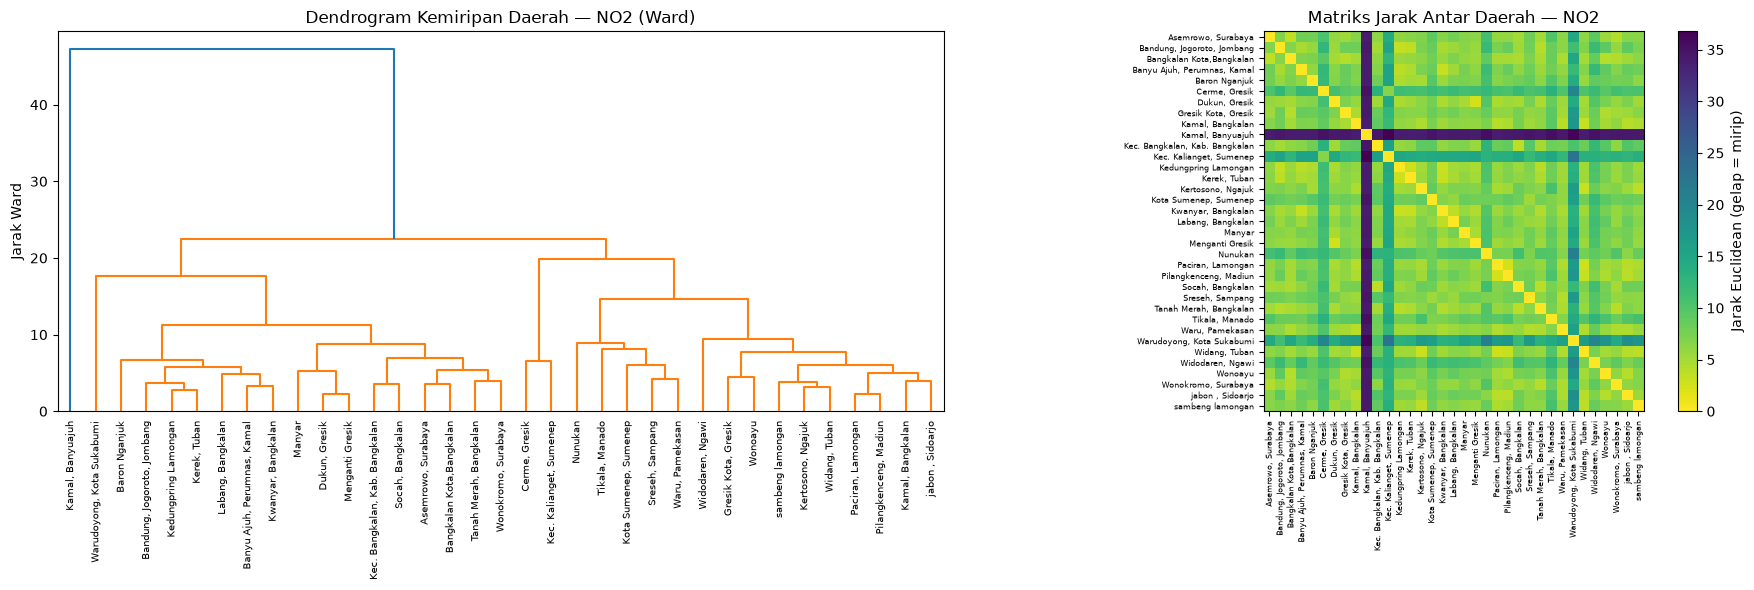

Tersimpan: fig_no2_dendrogram_daerah.png
SO2: 35 daerah unik dari 37 sampel


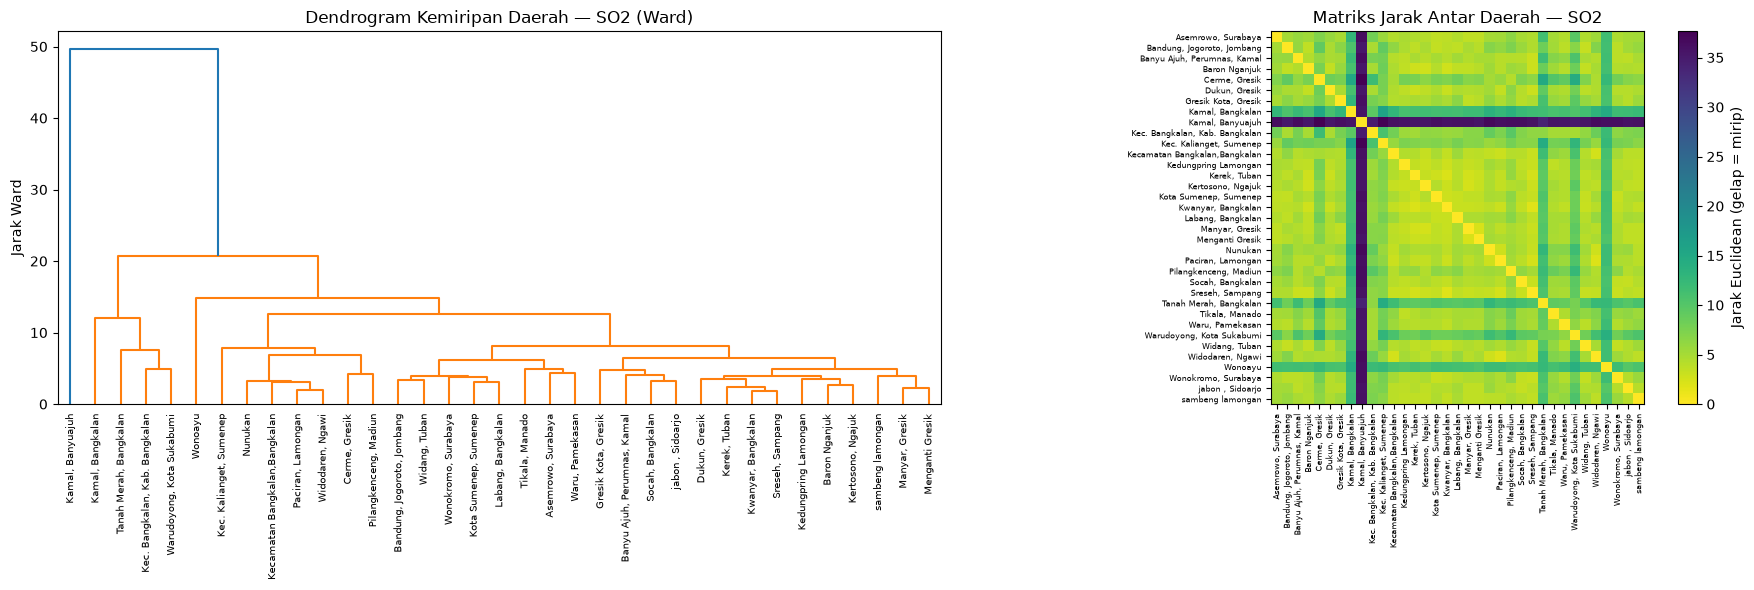

Tersimpan: fig_so2_dendrogram_daerah.png


In [18]:
for p in POLLUTANTS:
    df_p = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv')
    feat = [c for c in df_p.columns if c not in META_COLS]
    Xp = df_p[feat].values
    if np.isnan(Xp).sum() > 0:
        Xp = SimpleImputer(strategy='median').fit_transform(Xp)
    Xs = StandardScaler().fit_transform(Xp)
    
    # Profil tiap daerah = rata-rata fitur terstandarisasi anggotanya
    prof = pd.DataFrame(Xs, columns=feat)
    prof['daerah'] = df_p['daerah'].values
    g = prof.groupby('daerah').mean(numeric_only=True)
    daerah_names = list(g.index)
    Xd = g.values
    print(f'{p}: {len(daerah_names)} daerah unik dari {len(df_p)} sampel')
    
    Z = linkage(Xd, method='ward')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1.3, 1]})
    
    dendrogram(Z, labels=daerah_names, ax=ax1, leaf_rotation=90, leaf_font_size=7)
    ax1.set_title(f'Dendrogram Kemiripan Daerah — {p} (Ward)')
    ax1.set_ylabel('Jarak Ward')
    
    D = squareform(pdist(Xd, metric='euclidean'))
    im = ax2.imshow(D, cmap='viridis_r')
    ax2.set_xticks(range(len(daerah_names)))
    ax2.set_xticklabels(daerah_names, rotation=90, fontsize=6)
    ax2.set_yticks(range(len(daerah_names)))
    ax2.set_yticklabels(daerah_names, fontsize=6)
    ax2.set_title(f'Matriks Jarak Antar Daerah — {p}')
    plt.colorbar(im, ax=ax2, label='Jarak Euclidean (gelap = mirip)')
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_dendrogram_daerah.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Tersimpan: fig_{p.lower()}_dendrogram_daerah.png")

--- CO: daerah per cluster (kondisi sama) ---
Cluster 0 (34 daerah): Asemrowo, Surabaya; Bandung, Jogoroto, Jombang; Banyu Ajuh, Perumnas, Kamal; Baron Nganjuk; Cerme, Gresik; Dukun, Gresik; Gresik Kota, Gresik; Kamal, Bangkalan; Kec. Bangkalan, Kab. Bangkalan; Kec. Kalianget, Sumenep; Kecamatan Bangkalan,Bangkalan; Kedungpring Lamongan; Kerek, Tuban; Kertosono, Ngajuk; Kota Sumenep, Sumenep; Kwanyar, Bangkalan; Labang, Bangkalan; Manyar, Gresik; Menganti Gresik; Nunukan; Paciran, Lamongan; Pilangkenceng, Madiun; Socah, Bangkalan; Sreseh, Sampang; Tanah Merah, Bangkalan; Tikala, Manado; Waru, Pamekasan; Warudoyong, Kota Sukabumi; Widang, Tuban; Widodaren, Ngawi; Wonoayu; Wonokromo, Surabaya; jabon , Sidoarjo; sambeng lamongan
Cluster 1 (1 daerah): Kamal, Banyuajuh


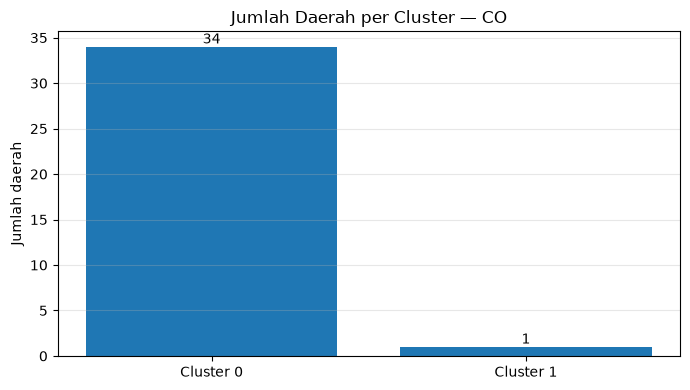

Tersimpan: fig_co_daerah_per_cluster.png
--- NO2: daerah per cluster (kondisi sama) ---
Cluster 0 (34 daerah): Asemrowo, Surabaya; Bandung, Jogoroto, Jombang; Bangkalan Kota,Bangkalan; Banyu Ajuh, Perumnas, Kamal; Baron Nganjuk; Cerme, Gresik; Dukun, Gresik; Gresik Kota, Gresik; Kamal, Bangkalan; Kec. Bangkalan, Kab. Bangkalan; Kec. Kalianget, Sumenep; Kedungpring Lamongan; Kerek, Tuban; Kertosono, Ngajuk; Kota Sumenep, Sumenep; Kwanyar, Bangkalan; Labang, Bangkalan; Manyar; Menganti Gresik; Nunukan; Paciran, Lamongan; Pilangkenceng, Madiun; Socah, Bangkalan; Sreseh, Sampang; Tanah Merah, Bangkalan; Tikala, Manado; Waru, Pamekasan; Warudoyong, Kota Sukabumi; Widang, Tuban; Widodaren, Ngawi; Wonoayu; Wonokromo, Surabaya; jabon , Sidoarjo; sambeng lamongan
Cluster 1 (1 daerah): Kamal, Banyuajuh


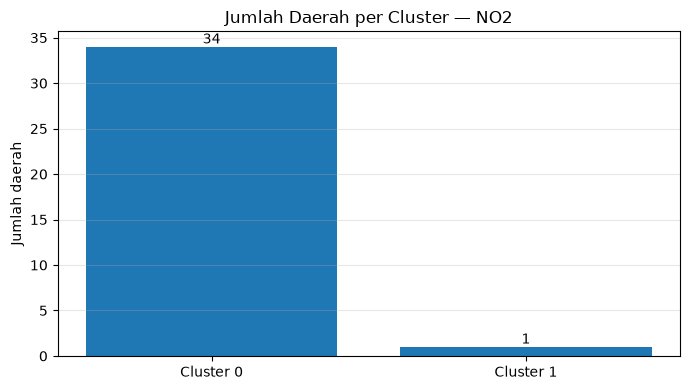

Tersimpan: fig_no2_daerah_per_cluster.png
--- SO2: daerah per cluster (kondisi sama) ---
Cluster 0 (34 daerah): Asemrowo, Surabaya; Bandung, Jogoroto, Jombang; Banyu Ajuh, Perumnas, Kamal; Baron Nganjuk; Cerme, Gresik; Dukun, Gresik; Gresik Kota, Gresik; Kamal, Bangkalan; Kec. Bangkalan, Kab. Bangkalan; Kec. Kalianget, Sumenep; Kecamatan Bangkalan,Bangkalan; Kedungpring Lamongan; Kerek, Tuban; Kertosono, Ngajuk; Kota Sumenep, Sumenep; Kwanyar, Bangkalan; Labang, Bangkalan; Manyar, Gresik; Menganti Gresik; Nunukan; Paciran, Lamongan; Pilangkenceng, Madiun; Socah, Bangkalan; Sreseh, Sampang; Tanah Merah, Bangkalan; Tikala, Manado; Waru, Pamekasan; Warudoyong, Kota Sukabumi; Widang, Tuban; Widodaren, Ngawi; Wonoayu; Wonokromo, Surabaya; jabon , Sidoarjo; sambeng lamongan
Cluster 1 (1 daerah): Kamal, Banyuajuh


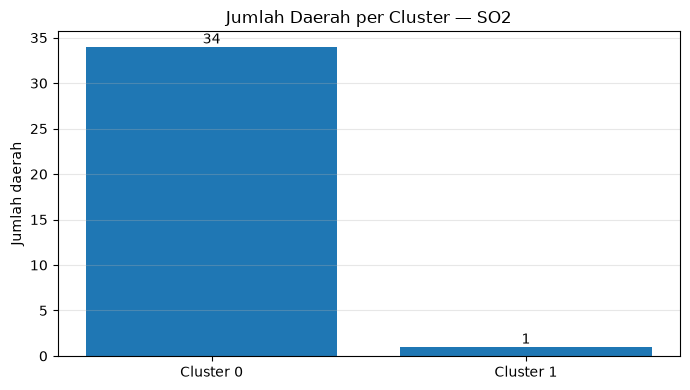

Tersimpan: fig_so2_daerah_per_cluster.png


In [19]:
for p in POLLUTANTS:
    df_map = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv', usecols=META_COLS)
    df_map['cluster'] = labels_dict[p]['labels_68']
    # Cluster dominan tiap daerah (mayoritas sampelnya)
    dom = df_map.groupby('daerah')['cluster'].agg(lambda s: s.mode().iloc[0]).astype(int)
    print(f'--- {p}: daerah per cluster (kondisi sama) ---')
    for c in sorted(df_map['cluster'].unique()):
        ds = sorted(dom[dom == c].index.tolist())
        print(f'Cluster {c} ({len(ds)} daerah): ' + '; '.join(ds))
    
    cnt = dom.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    b = ax.bar([f'Cluster {c}' for c in cnt.index], cnt.values)
    ax.bar_label(b)
    ax.set_ylabel('Jumlah daerah')
    ax.set_title(f'Jumlah Daerah per Cluster — {p}')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_daerah_per_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Tersimpan: fig_{p.lower()}_daerah_per_cluster.png")

## 5.2.14 Kesimpulan

1. **Silhouette Score** yang lebih tinggi menunjukkan cluster yang lebih terpisah dan compact.
2. Diagram silhouette per sampel (5.2.6) + histogram jarak (5.2.9) menunjukkan K=2 beranggotakan 36-vs-1: skor tinggi didorong satu outlier jauh, bukan dua kelompok seimbang — perlu kehati-hatian interpretasi.
3. Heatmap centroid & Top-10 fitur pembeda (5.2.8) + boxplot (5.2.9) menjelaskan *mengapa* outlier terpisah.
4. Crosstab cluster vs daerah (5.2.7) menguji apakah pemisahan berkaitan dengan lokasi spasial.
5. Jika Skenario 2 (PCA) menghasilkan silhouette yang lebih baik atau setara → PCA efektif mereduksi noise.
6. Jika Skenario 1 lebih baik → fitur asli masih lebih informatif.
7. Analisis sensitivitas (5.2.11): setelah outlier (Dewi Geizya, Kamal Banyuajuh) dikeluarkan, K optimal tetap 2 namun silhouette turun — CO 0.7955→0.6737, NO₂ 0.7455→0.3992, SO₂ 0.7894→0.6501 — menegaskan skor tinggi sebelumnya didorong outlier, terutama pada NO₂.
8. Kemiripan daerah (5.2.13): 34 dari 35 daerah jatuh dalam satu cluster (kondisi sama) pada ketiga polutan; hanya `Kamal, Banyuajuh` yang selalu menyendiri. Pasangan daerah paling mirip: CO = Gresik Kota ↔ Socah Bangkalan; NO₂ = Paciran Lamongan ↔ Pilangkenceng Madiun; SO₂ = Sreseh Sampang ↔ Kwanyar Bangkalan.
9. Komparasi lengkap ada di notebook 5.3.